In [131]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import os

# omite advertencias
import warnings
warnings.filterwarnings("ignore")

In [132]:
df = pd.read_csv("../data/Telco_Customer_Churn_Dataset.csv")

In [133]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [134]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

# 1. Manipulación de Datos

In [135]:
# transforma str a object
for columna in df.select_dtypes(include=['string']).columns:
        df[columna] = df[columna].astype('object')

In [136]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [137]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 
 17  Paymen

In [138]:
# obtiene valores únicos por variable
for columna in df.select_dtypes(include=['object']).columns:
    if columna != 'customerID': 
        print(df[columna].name)
        print(df[columna].unique())
        print(f"Total únicos: {df[columna].nunique()}")

gender
['Female' 'Male']
Total únicos: 2
Partner
['Yes' 'No']
Total únicos: 2
Dependents
['No' 'Yes']
Total únicos: 2
PhoneService
['No' 'Yes']
Total únicos: 2
MultipleLines
['No phone service' 'No' 'Yes']
Total únicos: 3
InternetService
['DSL' 'Fiber optic' 'No']
Total únicos: 3
OnlineSecurity
['No' 'Yes' 'No internet service']
Total únicos: 3
OnlineBackup
['Yes' 'No' 'No internet service']
Total únicos: 3
DeviceProtection
['No' 'Yes' 'No internet service']
Total únicos: 3
TechSupport
['No' 'Yes' 'No internet service']
Total únicos: 3
StreamingTV
['No' 'Yes' 'No internet service']
Total únicos: 3
StreamingMovies
['No' 'Yes' 'No internet service']
Total únicos: 3
Contract
['Month-to-month' 'One year' 'Two year']
Total únicos: 3
PaperlessBilling
['Yes' 'No']
Total únicos: 2
PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Total únicos: 4
Churn
['No' 'Yes']
Total únicos: 2


# 2. Análisis Exploratorio de Datos

In [139]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [140]:
# estadísticas descriptivas de variables categóricas
df.describe(include="object").T.drop("customerID", axis=0)

,count,unique,top,freq
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095
TechSupport,7043,3,No,3473


In [141]:
# estadísticas descriptivas de variables numéricas
# describe variables numéricas (excluye SeniorCitizen)
df.describe(include=['int64', 'float64']).T.drop("SeniorCitizen", axis=0)

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


## duplicados

In [142]:
# busca duplicados por customerID
df.duplicated(subset=['customerID']).sum()

np.int64(0)

## outliers

Text(0.5, 1.0, 'TotalCharges')

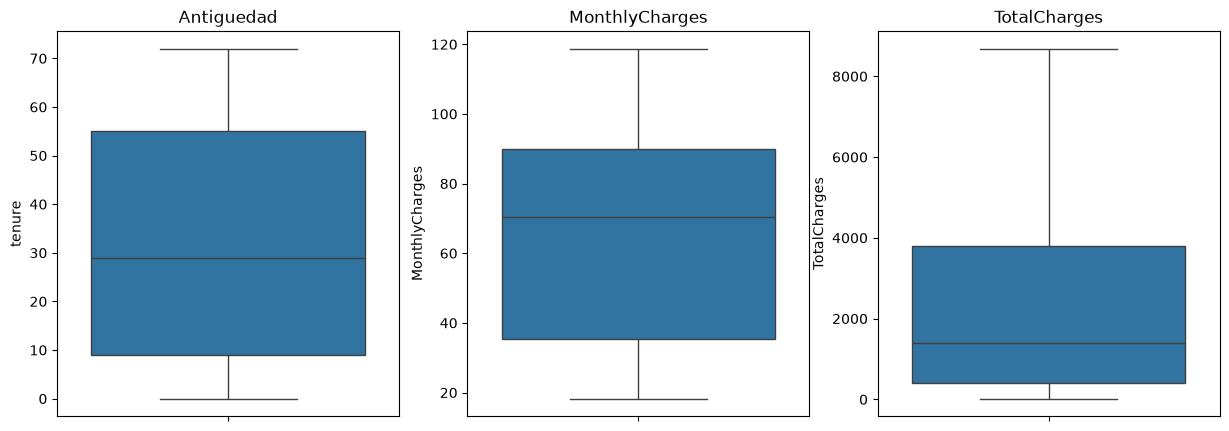

In [143]:
# Crear una figura con múltiples espacios (ejemplo: 1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Dibujar cada gráfico de caja en un eje distinto
sns.boxplot(y=df["tenure"], ax=axes[0])
axes[0].set_title("Antiguedad")

sns.boxplot(y=df["MonthlyCharges"], ax=axes[1])
axes[1].set_title("MonthlyCharges")

sns.boxplot(y=df["TotalCharges"], ax=axes[2])
axes[2].set_title("TotalCharges")

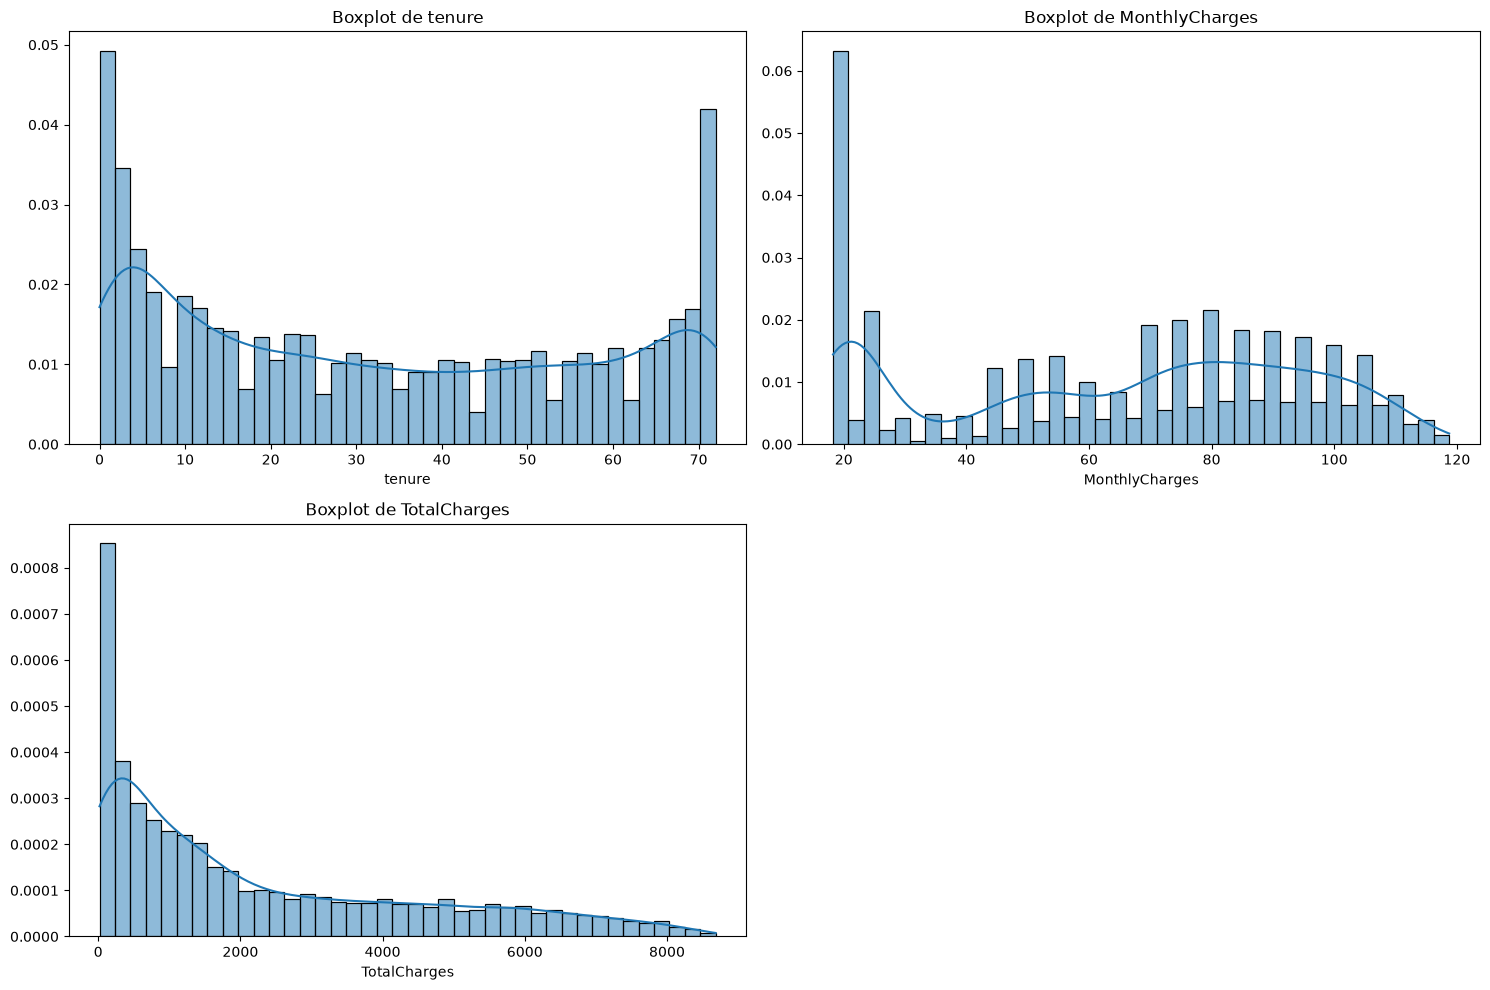

In [144]:
columnas_numericas = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15, 10))
for i, column in enumerate(columnas_numericas):
    plt.subplot(2, 2, i + 1)  # 2 rows, 2 columns
    sns.histplot(x=df[column], bins=40, kde=True, stat="density", common_norm=False)
    plt.title(f'Boxplot de {column}')
    plt.ylabel('') # Remove y-axis label to avoid clutter
plt.tight_layout()
plt.show()

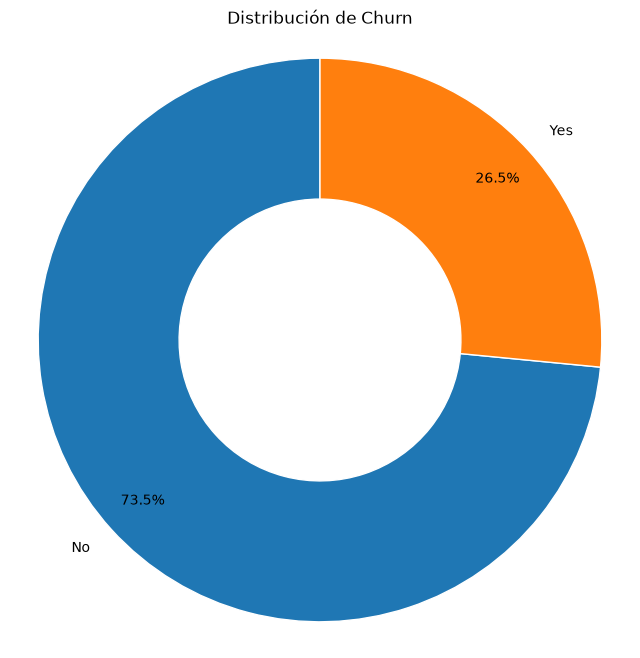

In [145]:
# Gráfico de rosquilla para la distribución de churn
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
    wedgeprops={'width': 0.5, 'edgecolor': 'white'}
)
plt.title('Distribución de Churn')
plt.axis('equal')
plt.show()


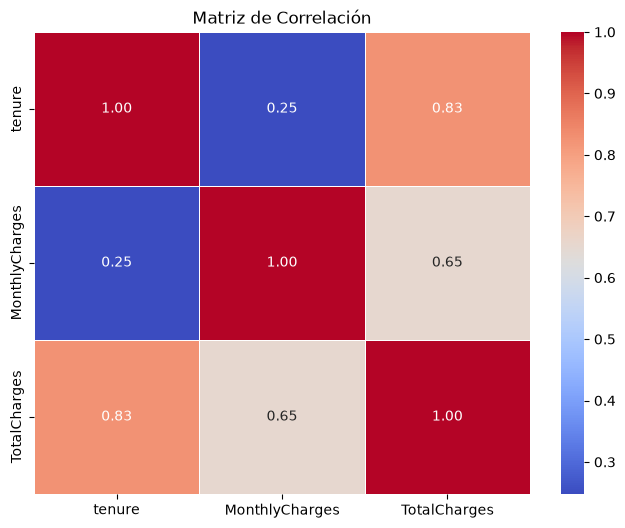

In [146]:
# correlación de variables numéricas
correlation_matrix = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()

# dibuja la matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

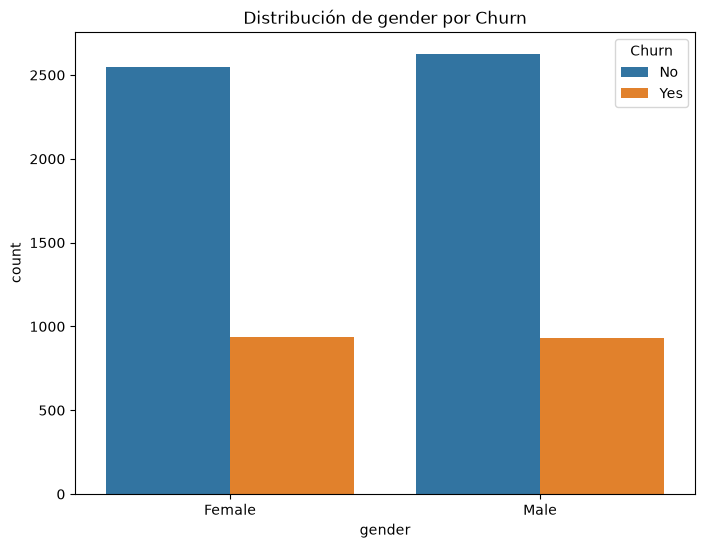

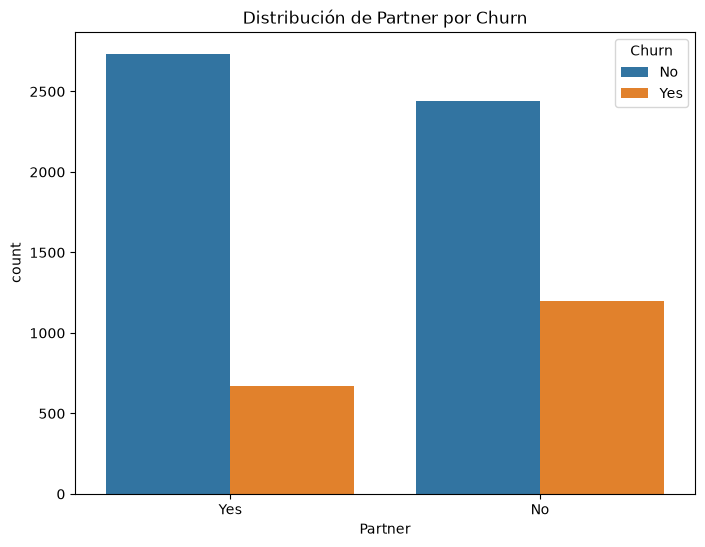

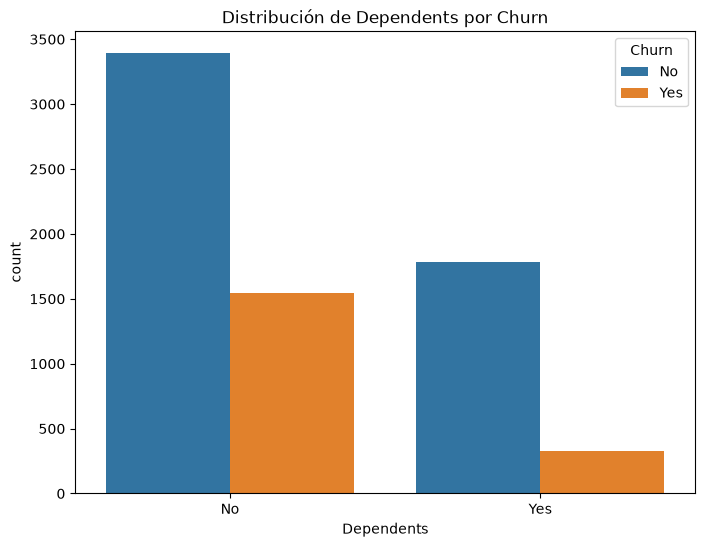

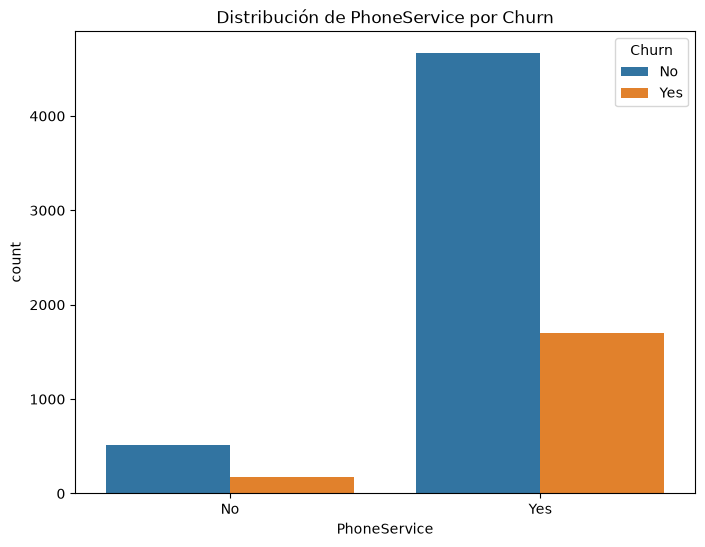

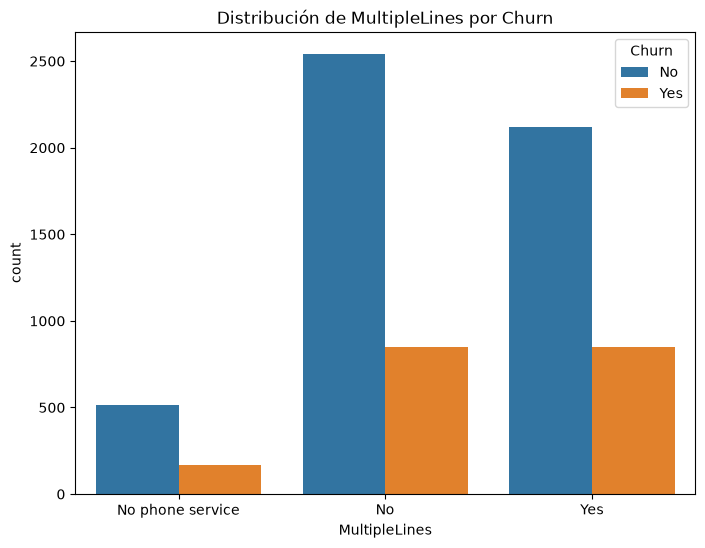

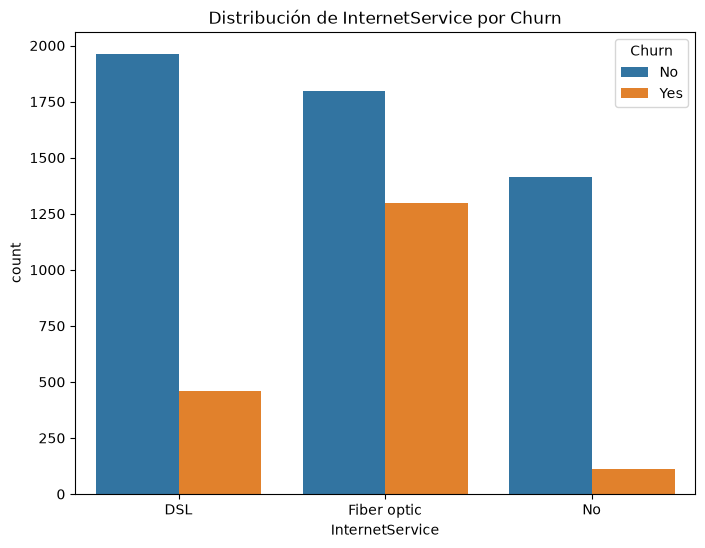

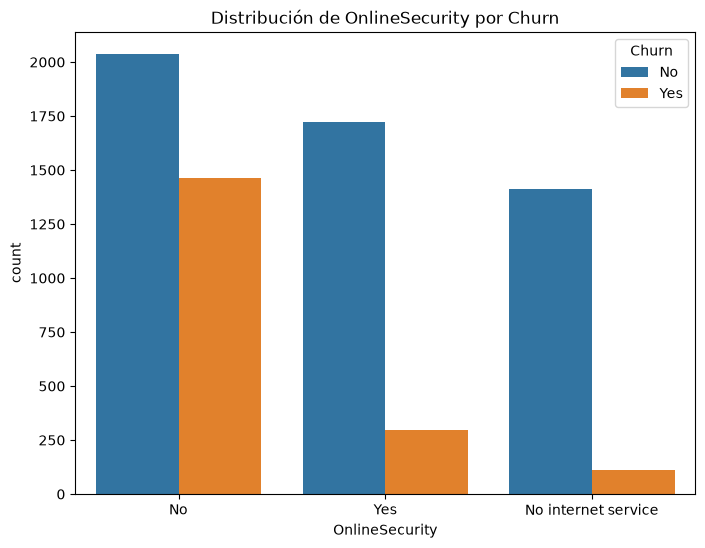

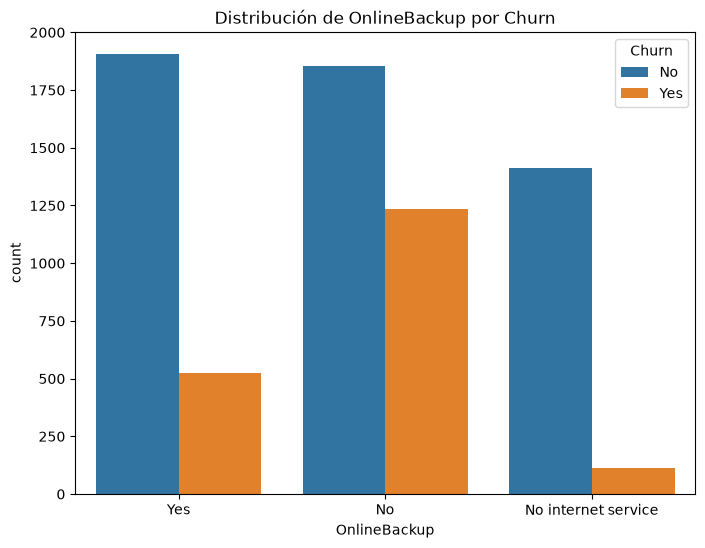

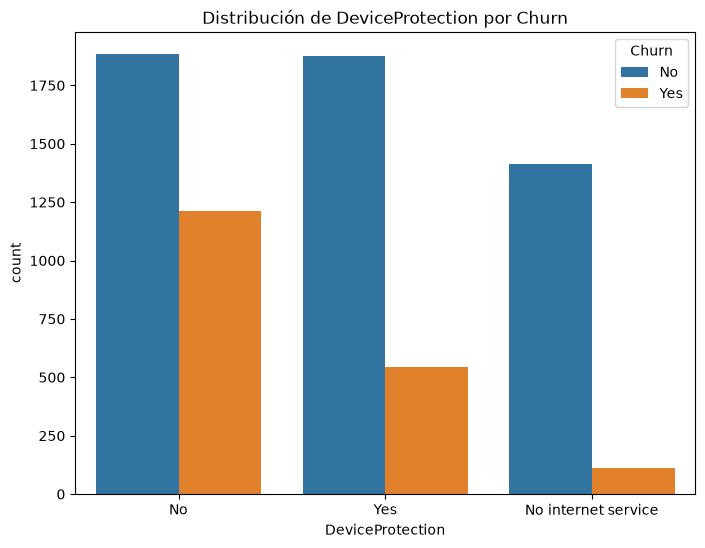

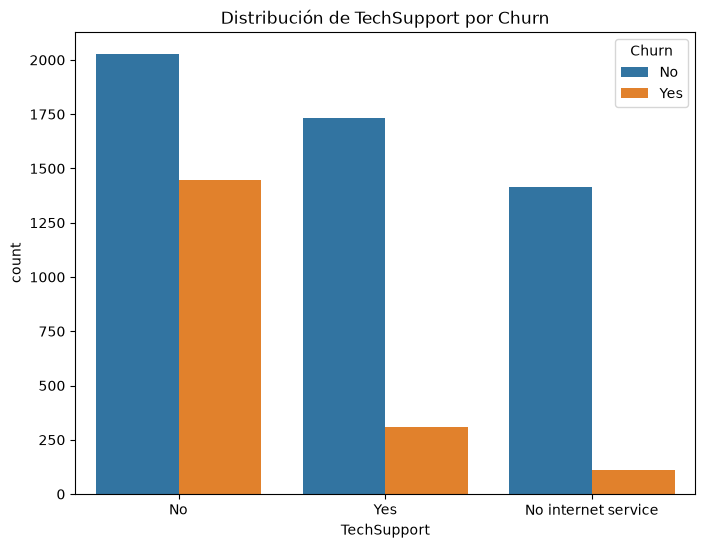

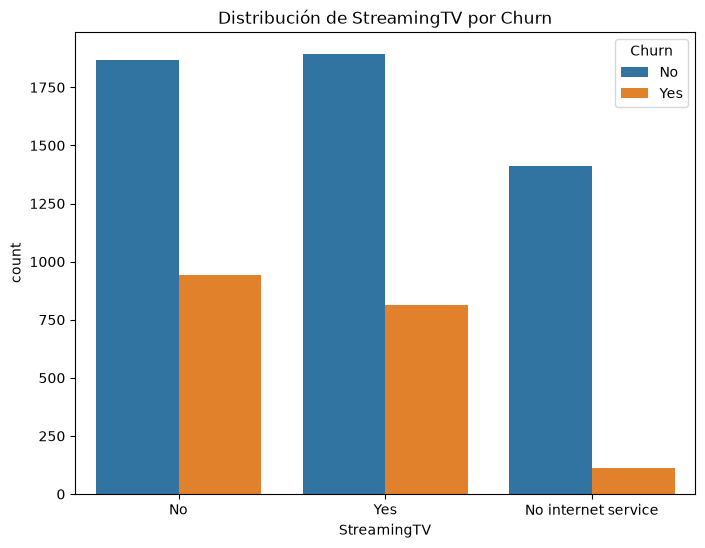

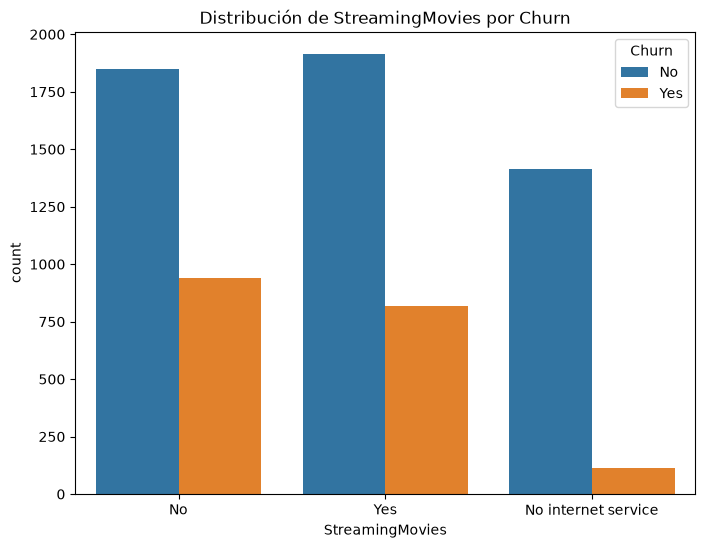

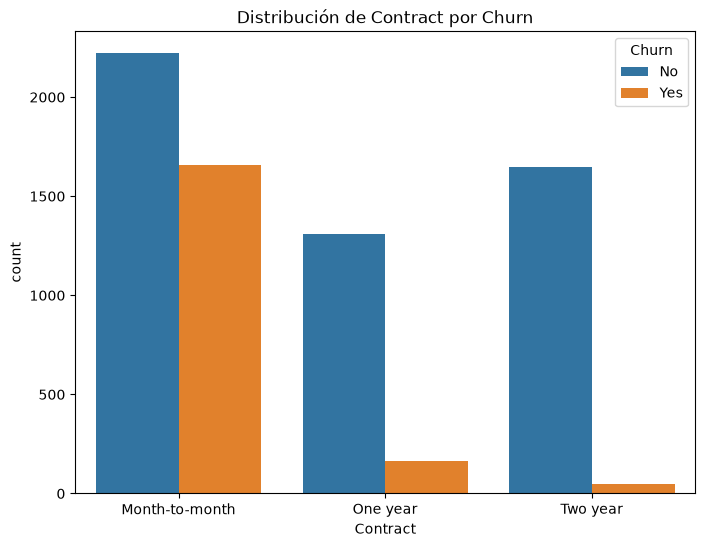

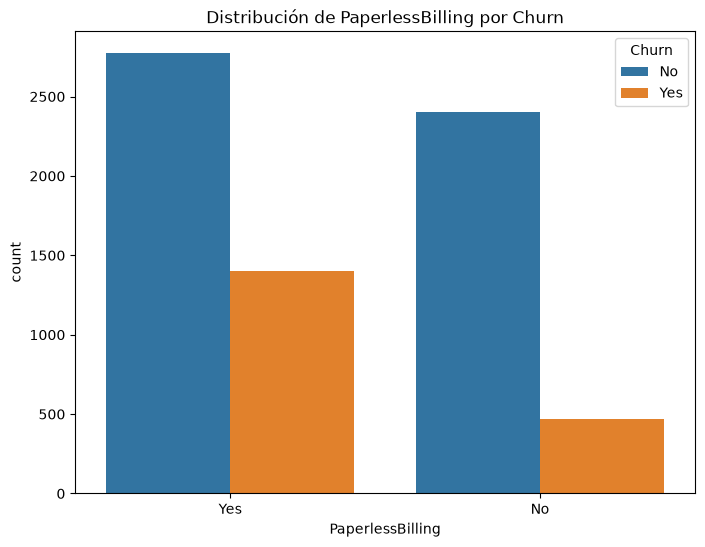

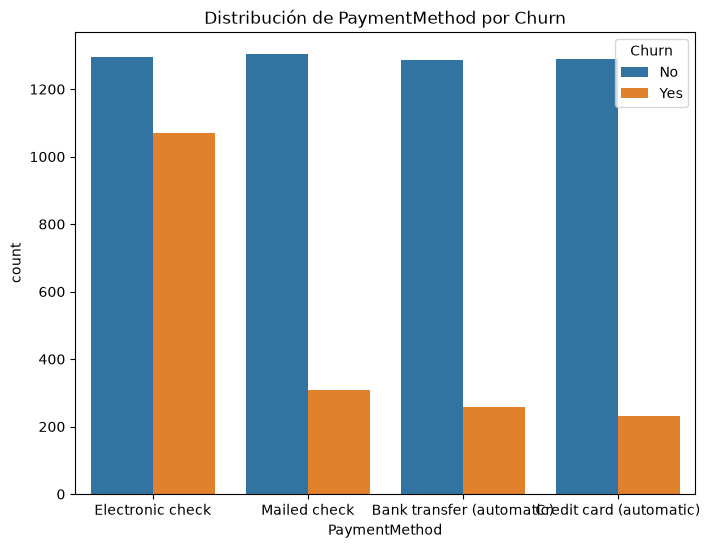

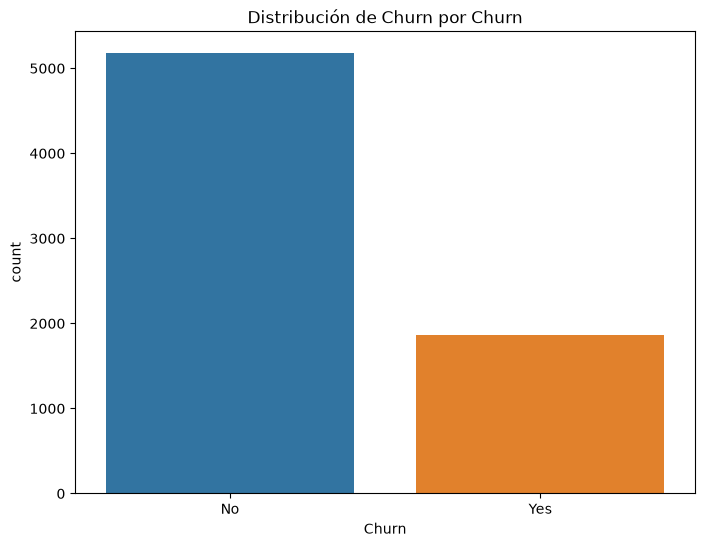

In [147]:
# correlación de variables categóricas con churn
categorical_columns = df.select_dtypes(include=['object']).columns.drop('customerID')

for col in categorical_columns:
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df, x=col, hue='Churn')
    plt.title(f'Distribución de {col} por Churn')
    plt.show()